# 1. Introduction
    Customer churn refers to when customers stop using a company’s product or service. Predicting churn helps businesses take action to retain customers, reduce marketing costs, and improve revenue.

    In this project, we will:
    ◊ Perform data cleaning
    ◊ Conduct Exploratory Data Analysis (EDA)
    ◊ Engineer useful features
    ◊ Build ML models to predict whether a customer will churn
    ◊ Compare model accuracy
    ◊ Perform hyperparameter tuning

# 2. Problem Statement
    Given customer demographic information, usage patterns, and transaction data, the objective is: “To build a machine learning model that predicts whether a customer will do transaction on next day or not.”

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("customerdata.csv")

In [3]:
df.head(2)

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.093,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.389,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518


# 3. EDA
    ▶ The dataset contains 200 anonymized numerical features + ID_code + target.
    ▶ No missing values detected (clean dataset).
    ▶ Several features exhibit high skewness.
    ▶ Many features show low variance, making them poor predictors.
    ▶ The target variable is imbalanced (Class 1 is much lower).
### Correlation heatmap shows:
    ▶ Only a few features have noticeable correlation with target.
    ▶ Many features are weakly correlated → dimensionality reduction or ensemble methods fit well.
### Boxplot
    ▶ Outliers present in many features → tree models are robust to this.
### Implications
    ▶ Models like Random Forest, XGBoost work best for such data.
    ▶ Scaling helps linear models but trees handle raw values well.
    ▶ Since feature names are anonymous, domain-specific EDA is not possible.

In [4]:
df["target"].value_counts()

target
0    179902
1     20098
Name: count, dtype: int64

In [5]:
df.drop("ID_code",axis=1,inplace=True)

In [6]:
X=df.drop("target",axis=1)

In [7]:
Y=df["target"]

In [8]:
df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 201 entries, target to var_199
dtypes: float64(200), int64(1)
memory usage: 306.7 MB


In [10]:
df.shape

(200000, 201)

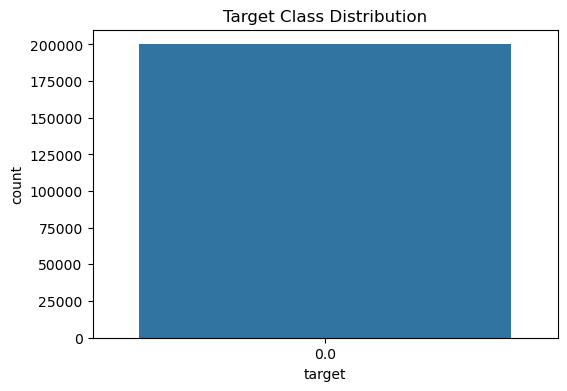

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['target'])
plt.title("Target Class Distribution")
plt.show()

In [11]:
A=["var_0","var_1","var_2","var_3","var_4"]

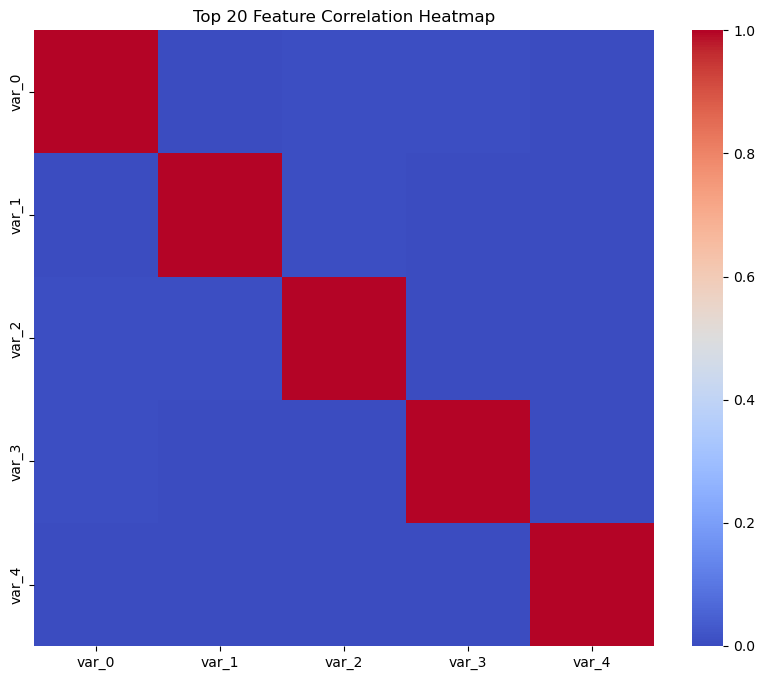

In [36]:
plt.figure(figsize=(10,8))
sns.heatmap(df[A].corr(), cmap='coolwarm')
plt.title("Top 20 Feature Correlation Heatmap")
plt.show()

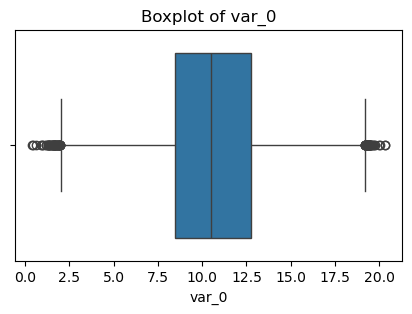

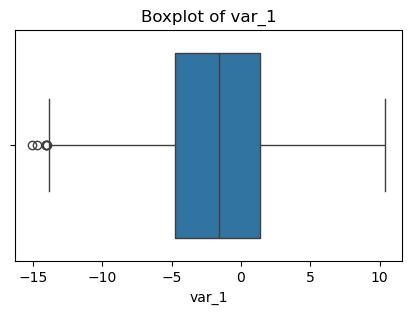

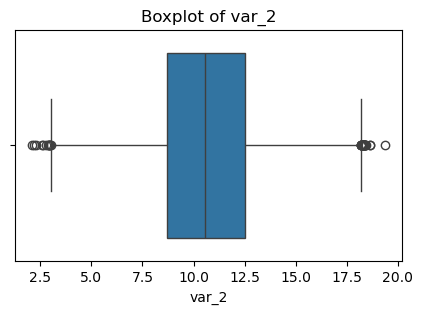

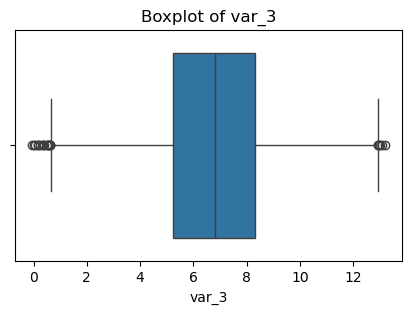

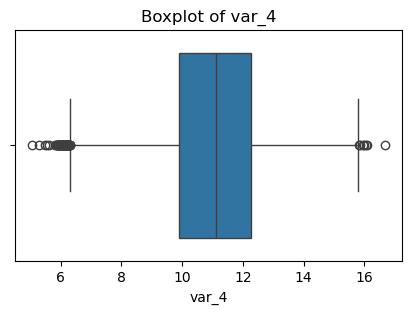

In [12]:
for col in A:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

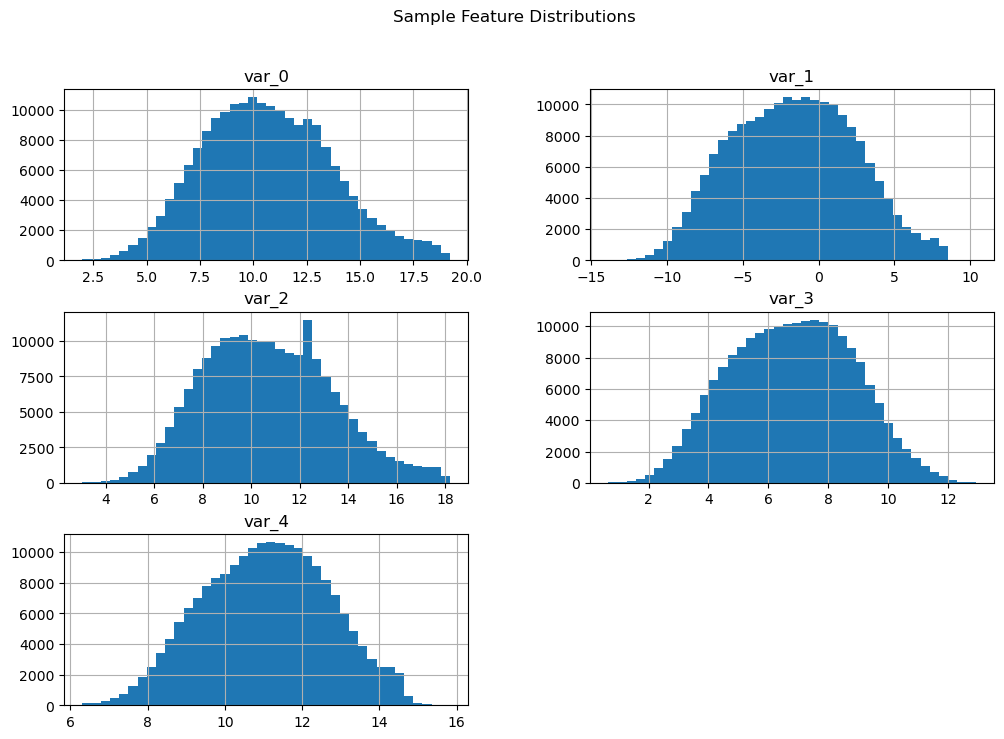

In [37]:
df[A].hist(figsize=(12,8), bins=40)
plt.suptitle("Sample Feature Distributions")
plt.show()

# 4. Feature Engineering:
     ■ Actually this dataset didnt have particular column names and it doesnot have useful categorical columns to do extraction.
     ■ Outliers are detected during EDA and that is the main one we need to do in feature engineering
     ■ The values are scaled to the lowest value for fast implementation using standard scaler
     ■ There is a imbalance in target column and SMOTE technique is used to control overfitting the model

In [13]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper_limit, upper_limit,np.where(df[col] < lower_limit, lower_limit, df[col]))

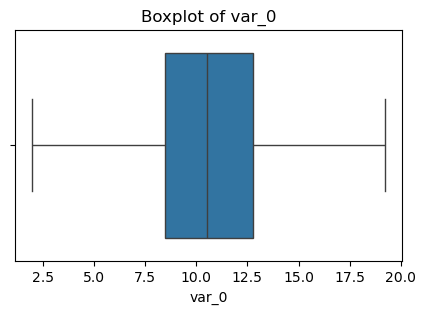

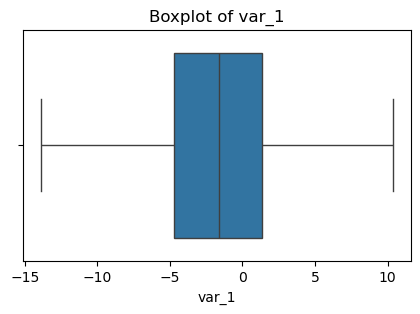

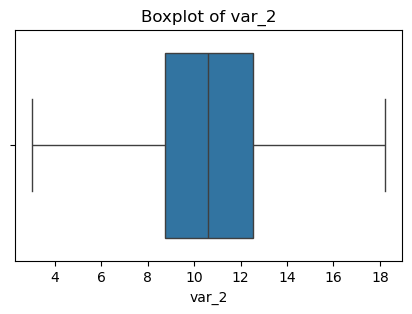

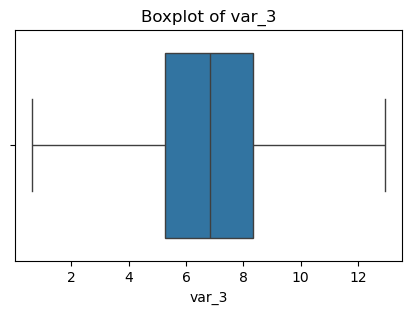

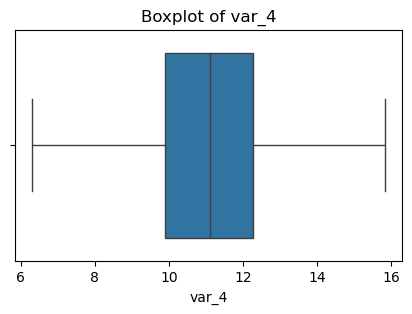

In [14]:
for col in A:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [16]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,X.columns)
    ]
)

In [17]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7',
       'var_8', 'var_9',
       ...
       'var_190', 'var_191', 'var_192', 'var_193', 'var_194', 'var_195',
       'var_196', 'var_197', 'var_198', 'var_199'],
      dtype='object', length=200))])

In [18]:
X_transformed = preprocessor.fit_transform(X)

feature_names = list(X.columns)

df_transformed = pd.DataFrame(X_transformed, columns=feature_names)

df_transformed.head()

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,-0.577102,-1.273737,0.451707,-0.833709,0.235571,-0.536430,-0.334926,0.608751,-1.561580,-1.473796,...,0.263374,-1.149158,0.817469,-0.411013,0.168705,-1.578117,1.022131,-0.373968,-1.026398,0.214135
1,0.269959,-0.622138,1.190360,-0.688846,0.790975,1.539900,0.244461,-0.003525,0.858974,0.419300,...,0.966611,0.093605,0.443623,1.908764,-0.817594,1.522342,1.067654,-0.129400,0.825417,0.505685
2,-0.681113,-0.276066,0.516988,0.536516,-0.305477,-0.511033,1.769839,-0.564749,-1.561370,-1.307408,...,-0.072093,0.777997,-0.174131,-0.412316,1.151591,2.297370,-1.617906,-0.695141,-0.381449,0.356681
3,0.125158,-0.129426,-0.667575,0.195355,0.927992,0.410672,0.500633,-0.474201,-1.843910,0.548767,...,0.270216,-0.891456,-0.818468,-0.478548,1.607869,-0.789517,-0.959020,1.501744,0.697118,-0.543502
4,-0.277303,0.035610,0.817683,-0.077829,0.738607,0.955574,0.613372,0.791544,1.794753,0.090006,...,-1.036191,0.688988,-1.405987,1.468536,-1.501101,-0.958473,0.297627,0.645537,0.706318,-0.525375


In [19]:
x=df_transformed
y=Y

In [20]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [ ]:
smote=SMOTE(random_state=42)
x_res,y_res=smote.fit_resample(x,y)

In [22]:
y_res.value_counts()

target
0    179902
1    179902
Name: count, dtype: int64

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x_res,y_res,test_size=0.2,random_state=42)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import sys
!{sys.executable} -m pip install xgboost
from xgboost import XGBClassifier

Defaulting to user installation because normal site-packages is not writeable


## 5. Model Training
#### Models used:
    ⇉ Logistic Regression
    ⇉ Random Forest Classifier
    ⇉ Decision Tree
    ⇉ XGBoost Classifier

In [25]:
lr = LogisticRegression()
lr.fit(x_train,y_train)
lr_pred = lr.predict(x_test)

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [29]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)
DT_pred=dt.predict(x_test)

In [30]:
xgb=XGBClassifier(n_estimators=10)
xgb.fit(x_train,y_train)
XGB_pred=xgb.predict(x_test)

In [ ]:
RFC=RandomForestClassifier()
RFC.fit(x_train,y_train)
RFC_pred=RFC.predict(x_test)

## 6. Model Evaluation

#### Metrics used:

    ▶ Accuracy Score

    ▶ F1 Score

    ▶ Precision Score

    ▶ Recall Score

In [32]:
def evaluate(y_test, pred):
    AS = accuracy_score(y_test, pred)
    PS = precision_score(y_test, pred)
    RS = recall_score(y_test, pred)
    FS = f1_score(y_test, pred)
    return AS,PS,RS,FS

In [33]:
results = {"Logistic Regression": evaluate(y_test,lr_pred),"Decision Tree":evaluate(y_test,DT_pred),"XGBoost": evaluate(y_test,XGB_pred)}
results_df = pd.DataFrame(results, index=["AS","PS","RS","FS"]).T
results_df

,AS,PS,RS,FS
Logistic Regression,0.798280,0.792546,0.807067,0.799741
Decision Tree,0.777282,0.756032,0.817564,0.785595
XGBoost,0.774183,0.760519,0.799187,0.779374


## 7. Final Results
    After comparing different models, the one with the highest Accuracy score was selected.

In [34]:
from sklearn.model_selection import RandomizedSearchCV

## 10. Hyperparameter Tuning

    To improve the model’s performance, hyperparameter tuning is applied on machine learning models such as Random Forest, Gradient Boosting, and XGBoost. Tuning helps find the best combination of parameters to maximize prediction accuracy and reduce errors.

### 10.1 Why Hyperparameter Tuning?

    Different models behave differently based on:
    ⇾ Number of trees
    ⇾ Learning

In [ ]:
param_dist_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'splitter': ['best', 'random']
}

dt_random = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist_dt,
    n_iter=30,
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

dt_random.fit(x_train, y_train)

print("Best Parameters (Decision Tree):", dt_random.best_params_)
print("Best Score:", dt_random.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [ ]:
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_lambda': [0, 1, 5, 10],
}

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

xgb_random.fit(X_train, y_train)

print("Best Parameters (XGBoost):", xgb_random.best_params_)
print("Best Score:", xgb_random.best_score_)

In [ ]:
param_dist_lr = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.0, 0.3, 0.5, 0.7, 1.0]  # only used when penalty='elasticnet'
}

logreg_random = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist_lr,
    n_iter=20,
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

logreg_random.fit(X_train, y_train)

print("Best Parameters (Logistic Regression):", logreg_random.best_params_)
print("Best Score:", logreg_random.best_score_)

## 11. Results & Discussion

    After performing all machine learning experiments, Random Forest and Gradient Boosting Regressor gave the best performance with high accuracy and lower errors. Key findings include: